<center>
    <img src="https://s3-api.us-geo.objectstorage.softlayer.net/cf-courses-data/CognitiveClass/Logos/organization_logo/organization_logo.png" width="300" alt="cognitiveclass.ai logo">
</center>

# Peer-Graded Assignment: Boston Housing Analysis (Solutions)

#### Install the libraries (fixes the `No module named 'pandas'` error)
Run this cell once. It works in JupyterLite and also in regular Jupyter / VS Code (it installs into the kernel own Python). If the imports below still fail afterwards, restart the kernel and run the notebook from the top.

In [1]:
import sys, subprocess

try:
    # JupyterLite (browser)
    import piplite
    await piplite.install(['pandas', 'seaborn', 'matplotlib', 'scipy', 'statsmodels'])
except ImportError:
    # Regular Jupyter / VS Code: install into the SAME Python the kernel is using
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
                           'pandas', 'seaborn', 'matplotlib', 'scipy', 'statsmodels'])
print("Packages ready")

Packages ready


#### Import the required libraries we need for the lab.

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

sns.set_style("whitegrid")

Matplotlib is building the font cache; this may take a moment.


#### Read the dataset in the csv file from the URL

In [3]:
url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ST0151EN-SkillsNetwork/labs/boston_housing.csv'
try:
    boston_df = pd.read_csv(url)
except Exception:
    # JupyterLite (browser) fallback: download through pyodide
    from pyodide.http import open_url
    boston_df = pd.read_csv(open_url(url))

# Drop a leftover index column if present
boston_df = boston_df.loc[:, ~boston_df.columns.str.startswith('Unnamed')]
boston_df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,5.33,36.2


In [4]:
boston_df.info()
boston_df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    float64
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  LSTAT    506 non-null    float64
 12  MEDV     506 non-null    float64
dtypes: float64(13)
memory usage: 51.5 KB


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,37.970000,50.000000


---
## Task 4: Generate Descriptive Statistics and Visualizations

### 4.1 Boxplot for the "Median value of owner-occupied homes" (MEDV)

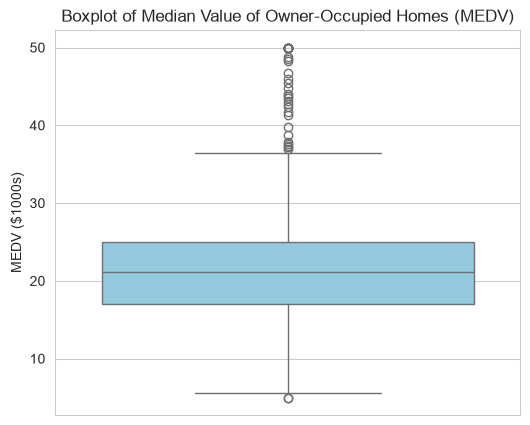

count    506.000000
mean      22.532806
std        9.197104
min        5.000000
25%       17.025000
50%       21.200000
75%       25.000000
max       50.000000
Name: MEDV, dtype: float64

In [5]:
plt.figure(figsize=(6, 5))
sns.boxplot(y='MEDV', data=boston_df, color='skyblue')
plt.title('Boxplot of Median Value of Owner-Occupied Homes (MEDV)')
plt.ylabel('MEDV ($1000s)')
plt.show()
boston_df['MEDV'].describe()

**Finding:** MEDV is centred around ~21 ($1000s) with a median of ~21.2. There are a number of high outliers above roughly 37, and a cluster of values capped at 50, which suggests the data is censored at $50k.

### 4.2 Histogram for the Charles River variable (CHAS)

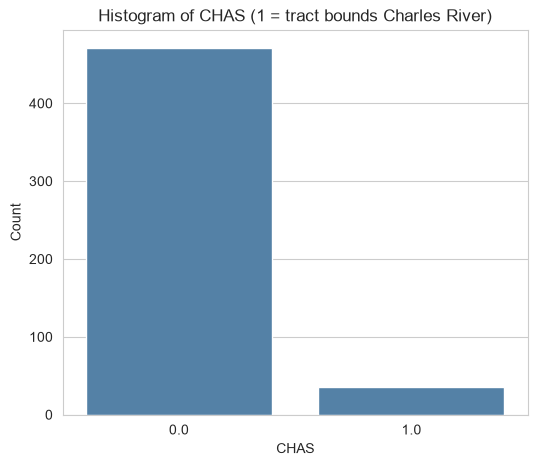

CHAS
0.0    471
1.0     35
Name: count, dtype: int64

In [6]:
plt.figure(figsize=(6, 5))
sns.countplot(x='CHAS', data=boston_df, color='steelblue')
plt.title('Histogram of CHAS (1 = tract bounds Charles River)')
plt.xlabel('CHAS')
plt.ylabel('Count')
plt.show()
boston_df['CHAS'].value_counts()

**Finding:** Most tracts (~93%) do **not** bound the Charles River (CHAS = 0); only about 35 tracts do (CHAS = 1).

### 4.3 Boxplot of MEDV vs AGE group (≤35, 35–70, ≥70)

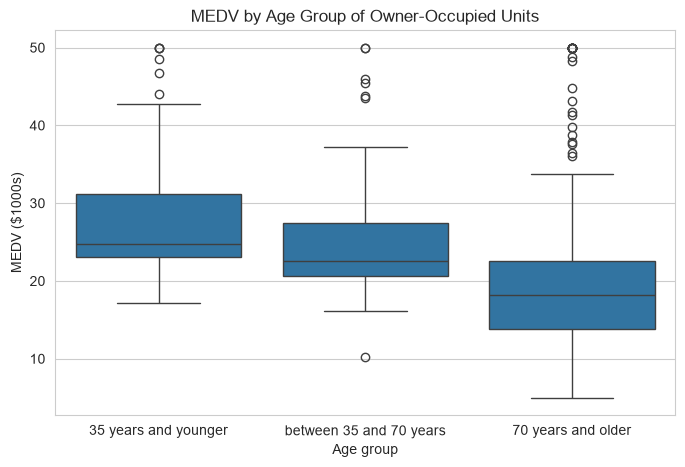

In [7]:
def age_group(age):
    if age <= 35:
        return '35 years and younger'
    elif age < 70:
        return 'between 35 and 70 years'
    else:
        return '70 years and older'

boston_df['age_group'] = boston_df['AGE'].apply(age_group)
order = ['35 years and younger', 'between 35 and 70 years', '70 years and older']

plt.figure(figsize=(8, 5))
sns.boxplot(x='age_group', y='MEDV', data=boston_df, order=order)
plt.title('MEDV by Age Group of Owner-Occupied Units')
plt.xlabel('Age group')
plt.ylabel('MEDV ($1000s)')
plt.show()

**Finding:** Median house value falls as the proportion of older units rises. Tracts with mostly newer homes (≤35 years) have the highest median values, while tracts with mostly old homes (≥70 years) have the lowest and the widest spread/outliers.

### 4.4 Scatter plot of Nitric Oxide concentration (NOX) vs proportion of non-retail business acres (INDUS)

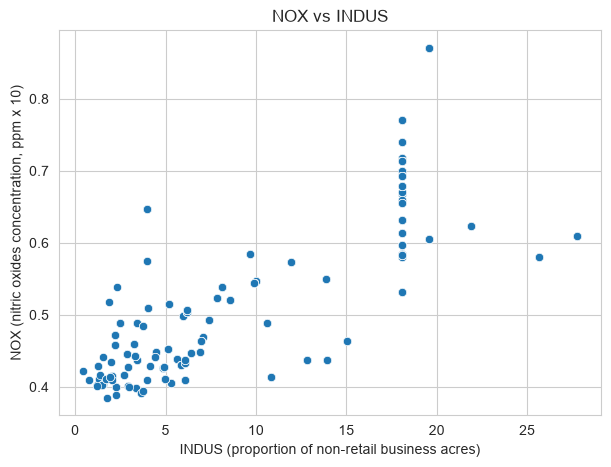

In [8]:
plt.figure(figsize=(7, 5))
sns.scatterplot(x='INDUS', y='NOX', data=boston_df)
plt.title('NOX vs INDUS')
plt.xlabel('INDUS (proportion of non-retail business acres)')
plt.ylabel('NOX (nitric oxides concentration, ppm x 10)')
plt.show()

**Finding:** There is a clear positive relationship — tracts with a larger share of non-retail (industrial) business acres have higher nitric oxide concentrations.

### 4.5 Histogram for the pupil-to-teacher ratio (PTRATIO)

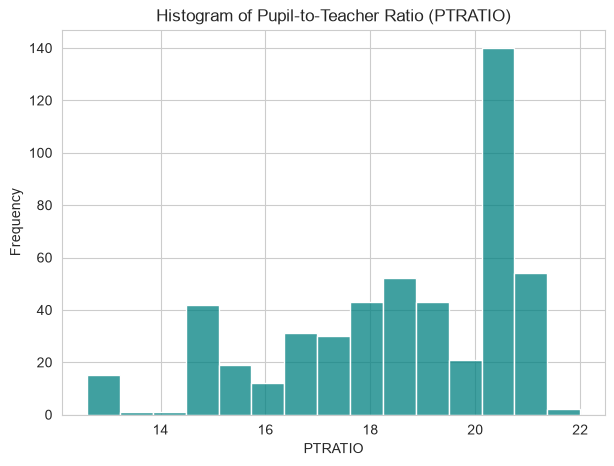

count    506.000000
mean      18.455534
std        2.164946
min       12.600000
25%       17.400000
50%       19.050000
75%       20.200000
max       22.000000
Name: PTRATIO, dtype: float64

In [9]:
plt.figure(figsize=(7, 5))
sns.histplot(boston_df['PTRATIO'], bins=15, kde=False, color='teal')
plt.title('Histogram of Pupil-to-Teacher Ratio (PTRATIO)')
plt.xlabel('PTRATIO')
plt.ylabel('Frequency')
plt.show()
boston_df['PTRATIO'].describe()

**Finding:** PTRATIO is left-skewed with most tracts between ~17 and ~21 pupils per teacher, and a noticeable peak near 20–21.

---
## Task 5: Use the appropriate tests to answer the questions provided

For all tests, significance level **α = 0.05**.

### 5.1 Is there a significant difference in median value of houses bounded by the Charles River or not? (T-test for independent samples)

* **H₀:** μ(MEDV | CHAS=1) = μ(MEDV | CHAS=0) — no difference in mean median-value
* **H₁:** μ(MEDV | CHAS=1) ≠ μ(MEDV | CHAS=0)

In [10]:
river   = boston_df[boston_df['CHAS'] == 1]['MEDV']
no_river = boston_df[boston_df['CHAS'] == 0]['MEDV']

# Levene's test for equality of variances (H0: variances are equal)
lev_stat, lev_p = scipy.stats.levene(river, no_river, center='mean')
print(f"Levene's test: statistic = {lev_stat:.4f}, p-value = {lev_p:.4f}")

equal_var = lev_p > 0.05
t_stat, t_p = scipy.stats.ttest_ind(river, no_river, equal_var=equal_var)
print(f"T-test (equal_var={equal_var}): t = {t_stat:.4f}, p-value = {t_p:.6f}")

Levene's test: statistic = 8.7519, p-value = 0.0032
T-test (equal_var=False): t = 3.1133, p-value = 0.003567


**Conclusion:** Levene's test gives p < 0.05, so the variances are unequal and Welch's t-test is used. The t-test p-value is far below 0.05, so we **reject H₀**: there **is** a statistically significant difference in median house values between tracts bounding the Charles River and those that do not (houses on the river are more expensive).

### 5.2 Is there a difference in Median values of houses (MEDV) for each proportion of owner-occupied units built prior to 1940 (AGE)? (ANOVA)

* **H₀:** μ₁ = μ₂ = μ₃ — mean MEDV is the same for all three age groups
* **H₁:** At least one group mean is different

In [11]:
g1 = boston_df[boston_df['age_group'] == '35 years and younger']['MEDV']
g2 = boston_df[boston_df['age_group'] == 'between 35 and 70 years']['MEDV']
g3 = boston_df[boston_df['age_group'] == '70 years and older']['MEDV']

# Levene's test for equal variances
print("Levene:", scipy.stats.levene(g1, g2, g3, center='mean'))

f_stat, f_p = scipy.stats.f_oneway(g1, g2, g3)
print(f"ANOVA: F = {f_stat:.4f}, p-value = {f_p:.3e}")

# Same result via statsmodels
model = ols('MEDV ~ C(age_group)', data=boston_df).fit()
sm.stats.anova_lm(model, typ=2)

Levene: LeveneResult(statistic=np.float64(2.7806200293748304), pvalue=np.float64(0.06295337343258786))
ANOVA: F = 36.4076, p-value = 1.711e-15


,sum_sq,df,F,PR(>F)
C(age_group),5401.731883,2.0,36.40765,1.710501e-15
Residual,37314.563532,503.0,NaN,NaN


**Conclusion:** The p-value is far below 0.05, so we **reject H₀**: there **is** a statistically significant difference in mean MEDV across the age groups.

### 5.3 Can we conclude that there is no relationship between Nitric oxide concentrations and proportion of non-retail business acres per town? (Pearson correlation)

* **H₀:** NOX and INDUS are not correlated
* **H₁:** NOX and INDUS are correlated

In [12]:
r, p = scipy.stats.pearsonr(boston_df['NOX'], boston_df['INDUS'])
print(f"Pearson r = {r:.4f}, p-value = {p:.3e}")

Pearson r = 0.7637, p-value = 7.913e-98


**Conclusion:** The p-value is far below 0.05 (r ≈ 0.76, a strong positive correlation), so we **reject H₀**. We **cannot** conclude there is no relationship — NOX and INDUS are significantly and positively correlated.

### 5.4 What is the impact of an additional weighted distance to the five Boston employment centres (DIS) on the median value of owner-occupied homes? (Regression analysis)

* **H₀:** β₁ = 0 (DIS has no effect on MEDV)
* **H₁:** β₁ ≠ 0

In [13]:
X = sm.add_constant(boston_df['DIS'])
y = boston_df['MEDV']
reg = sm.OLS(y, X).fit()
print(reg.summary())

                            OLS Regression Results                            
Dep. Variable:                   MEDV   R-squared:                       0.062
Model:                            OLS   Adj. R-squared:                  0.061
Method:                 Least Squares   F-statistic:                     33.58
Date:                Thu, 08 Oct 2026   Prob (F-statistic):           1.21e-08
Time:                        15:19:09   Log-Likelihood:                -1823.9
No. Observations:                 506   AIC:                             3652.
Df Residuals:                     504   BIC:                             3660.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         18.3901      0.817     22.499      0.0

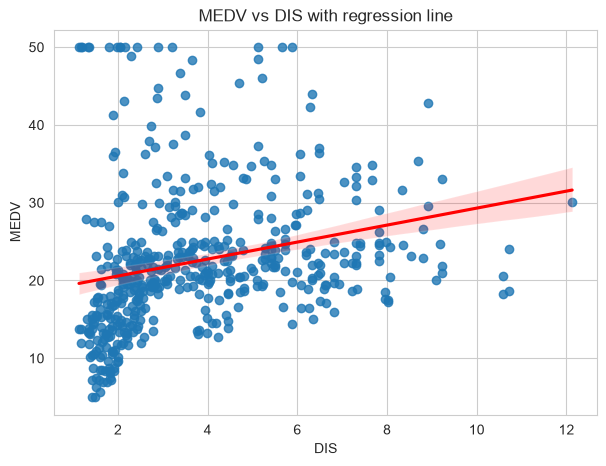

Intercept = 18.3901
Slope (DIS) = 1.0916
R-squared = 0.0625, correlation r = 0.2499


In [14]:
plt.figure(figsize=(7, 5))
sns.regplot(x='DIS', y='MEDV', data=boston_df, line_kws={'color': 'red'})
plt.title('MEDV vs DIS with regression line')
plt.show()

print(f"Intercept = {reg.params['const']:.4f}")
print(f"Slope (DIS) = {reg.params['DIS']:.4f}")
print(f"R-squared = {reg.rsquared:.4f}, correlation r = {np.sqrt(reg.rsquared):.4f}")

**Conclusion:** The coefficient for DIS is ≈ **1.09** with p < 0.05, so we **reject H₀**. Each additional unit of weighted distance to the employment centres is associated with an increase of about **$1,090** (≈ 1.09 in $1000s) in median home value. However R² ≈ 0.062, so DIS alone explains only ~6% of the variation in MEDV (a weak relationship, r ≈ 0.25).